In [1]:
from cereeberus import ReebGraph 

import cereeberus.data.ex_reebgraphs as ex_rg
import cereeberus.reeb.branchdecomp as branch
import numpy as np

import matplotlib.pyplot as plt

import uuid

%load_ext autoreload
%autoreload 2

Let's make sure the decomposition and reconstruction function is working first. Note that the vertex labels don't necessarily line up, but that's to be expected. 

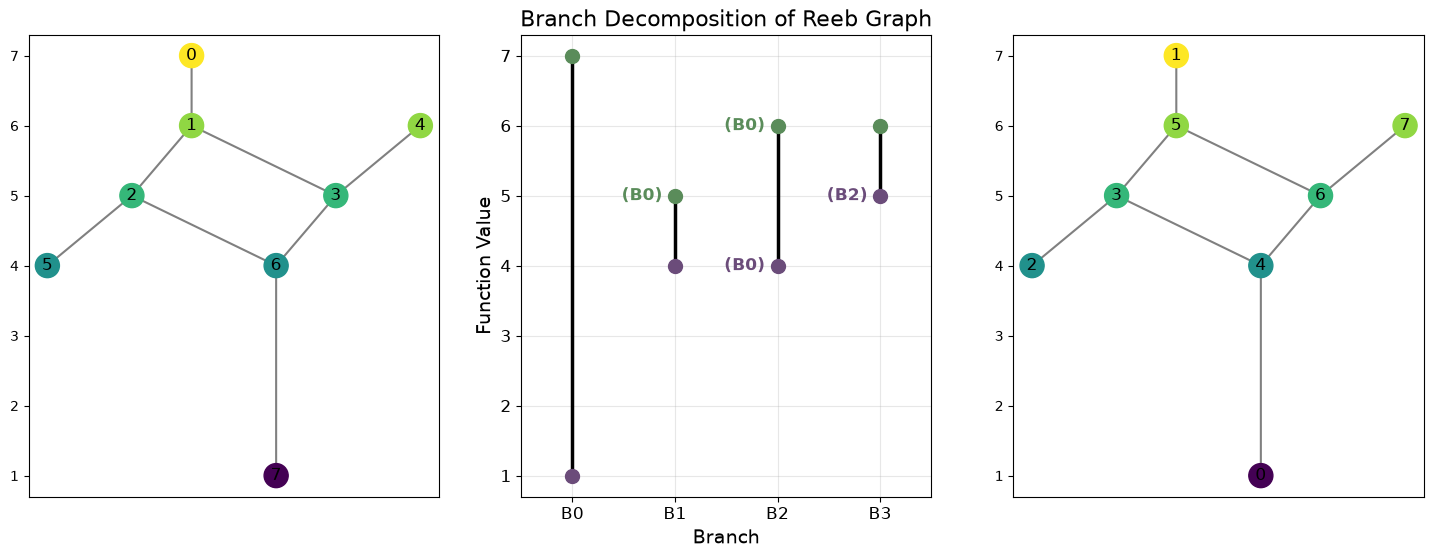

In [2]:
R = ex_rg.dancing_man()
B = branch.BranchDecomp(R)
R_recon = B.reconstruct()

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
R.draw(ax=axs[0])
B.draw(ax=axs[1])
R_recon.draw(ax=axs[2])


Now, I'm going to make a toy branch decomposition. I also manually set up the smoothed version of the Reeb graph for $\varepsilon = 1$, and manually set up the `branch_map` info from one to the next. More on why we need that later. 

[1, 2, 0]


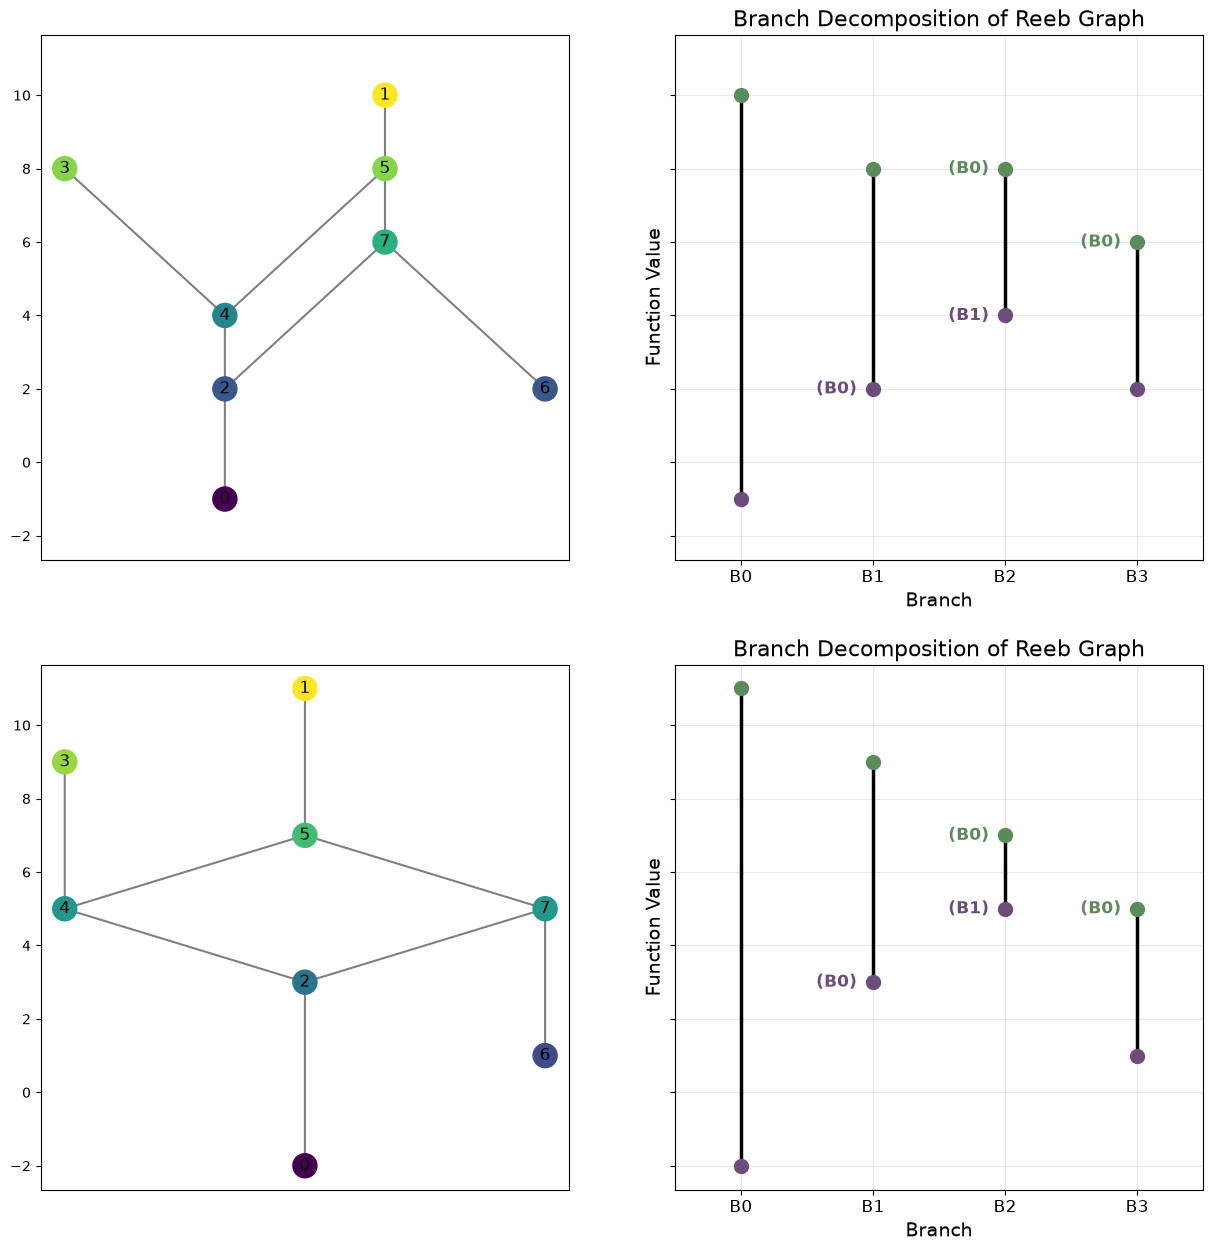

In [3]:
myB = branch.BranchDecomp()
myB.append(-1,10)
myB.append(2,8, bottom_branch = 0)
myB.append(4,8,bottom_branch = 1, top_branch = 0)
myB.append(2,6, top_branch = 0)


R = myB.reconstruct()
fig, ax = plt.subplots(2,2, figsize=(15,15),sharey=True)
R.draw(ax = ax[0,0]);
myB.draw(ax = ax[0,1]);

myB2 = branch.BranchDecomp()
myB2.append(-2,11)
myB2.append(3,9,bottom_branch = 0)
myB2.append(5,7,bottom_branch = 1, top_branch = 0)
myB2.append(1,5,top_branch = 0)

branch_map = branch.BranchDecompMap(myB, myB2)
branch_map.set_image(0, [0])
branch_map.set_image(1, [0,1])
branch_map.set_image(2, [1,2,0])
branch_map.set_image(3, [3,0])

print(branch_map[2])

myB2.draw(ax = ax[1,1]);
R2 = myB2.reconstruct()
R2.draw(ax = ax[1,0]);

## Branch paths

Ok, so I want to be able to talk about arbitrary up-paths given as a list of branches that I can follow up the Reeb graph. In this case, I can give you a list of branches with the following properties: 
- Denote the path entires as $[B_1,B_2,...,B_k]$. 
- Then for each $i$, either:
    - The top of $B_i$ is attached to $B_{i+1}$, or 
    - The bottom of $B_{i+1}$ is attached to $B_i$.
- Between each consecutive pair of branches, the property above gives a function value where the attaching happens, call this $a_i$. Then we need $a_i < a_{i+1}$ for all $i$.

The next function takes in a branch decomposition and a path given as a list of these branches, and then checks that all these properties are true. 

In [4]:
myB.check_branch_path([3,0])


True

So for the example, redrawn below so I can look at it easily, we could think about the path that follows vertices 0,2,4,3. This goes up along $B_0$, moves over to $B_1$ at height 2 (which is also vertex 2 for no good reason), then follows up branch $B_1$. So the representative branch path list would be $[B_0,B_1]$. 

Some more examples. 
- Vertex list 6,7,5,1 $\rightsquigarrow$ branch list $[B_3,B_0]$
- Vertex list 0,2,7,5,1 $\rightsquigarrow$ branch list $[B_0]$
- Vertex list 0,2,4,5,1 $\rightsquigarrow$ branch list $[B_0,B_1,B_2,B_0]$ (*notice I can have repeated branches*)
- Vertex list 0,2,4,3 $\rightsquigarrow$ branch list $[B_0,B_3]$.

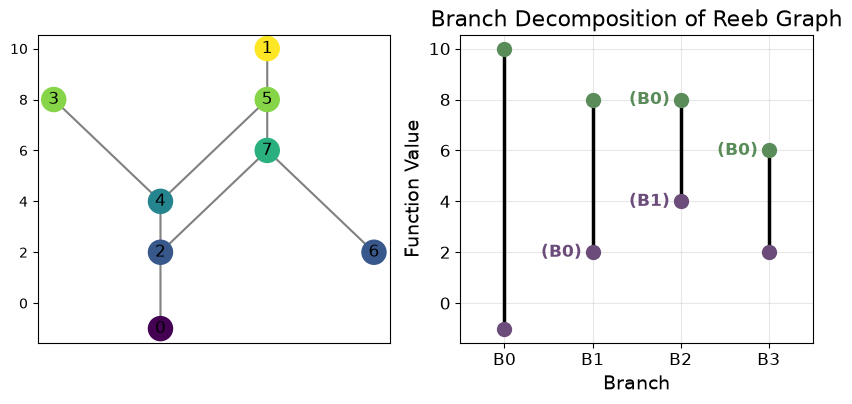

In [5]:
fig, ax = plt.subplots(1,2, figsize = (10,4))
myB.draw(ax = ax[1]);
myB.reconstruct().draw(ax = ax[0]);

So we can check these. We have the valid paths listed above, then some ones that won't work. Note that these are all paths I've made in `myB`.  

In [6]:
paths_to_check = [[0,1,2], [3,0], [0,1,2,0]]
paths_that_fail = [[0,3],[3,0,1], [0,2], [1,0,3]]

print("Checking valid paths:\n")
for path in paths_to_check:
    print(f"Check {path} is a valid path in myB: {myB.check_branch_path(path)}")
    
print("\nChecking invalid paths:\n")
for path in paths_that_fail:
    out = myB.check_branch_path(path)
    print(f"Check {path} is a valid path in myB: {out}") 

Checking valid paths:

Check [0, 1, 2] is a valid path in myB: True
Check [3, 0] is a valid path in myB: True
Check [0, 1, 2, 0] is a valid path in myB: True

Checking invalid paths:

Check [0, 3] is a valid path in myB: False
Check [3, 0, 1] is a valid path in myB: False
Check [0, 2] is a valid path in myB: False
Check [1, 0, 3] is a valid path in myB: False


I made that branch map thing above (although I haven't told you what it is yet), but let's make sure all the paths I made are valid in the second Reeb graph's decomposition. 

In [7]:
for i in range(len(myB)):
    print(f"Check {branch_map[i]} is a valid path in myB2: {myB2.check_branch_path(branch_map[i])}")

Check [0] is a valid path in myB2: True
Check [0, 1] is a valid path in myB2: True
Check [1, 2, 0] is a valid path in myB2: True
Check [3, 0] is a valid path in myB2: True


What will also be useful later is the ability to just get all those function values in between $B_i$ and $B_{i+1}$, so let's write a function for that. 

In [8]:
for path in paths_to_check:
    print(f"Function values along path {path}: {myB.get_func_vals_for_path(path)}")

Function values along path [0, 1, 2]: [2.0, 4.0]
Function values along path [3, 0]: [6.0]
Function values along path [0, 1, 2, 0]: [2.0, 4.0, 8.0]


## Subpaths of branch paths 

You give me a branch path, now I want to get the sublist of that thing that represents the stuff over the interval $[a,b] \subset \R$. Notice that if I tell you the interval $[a,a]$, you'll just give me the single branch that contains the function value $a$ in the path. 

Let's start by just testing this on single function values in `myB`. Note that these should return lists of length at most one, since we only want the point that is on the path at that height. 

At height 11, branch [] contains a point in the path.
At height 10, branch [0] contains a point in the path.
At height 9, branch [0] contains a point in the path.
At height 8, branch [2] contains a point in the path.
At height 7, branch [2] contains a point in the path.
At height 6, branch [2] contains a point in the path.
At height 5, branch [2] contains a point in the path.
At height 4, branch [2] contains a point in the path.
At height 3, branch [1] contains a point in the path.
At height 2, branch [1] contains a point in the path.
At height 1, branch [0] contains a point in the path.
At height 0, branch [0] contains a point in the path.
At height -1, branch [0] contains a point in the path.
At height -2, branch [] contains a point in the path.


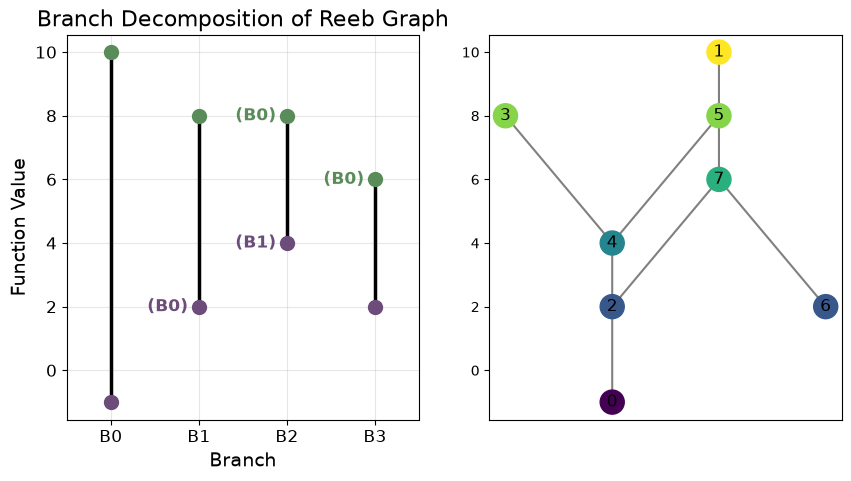

In [9]:
path = [0, 1, 2, 0]

for height in range(11, -3, -1):
    subpath = myB.find_subpath(path, height)
    branch_indices = [myB._index_of_branch(branch) for branch in subpath]
    print(f"At height {height}, branch {branch_indices} contains a point in the path.")

fig, ax = plt.subplots(1,2  , figsize = (10,5), sharey=True)
myB.draw(ax = ax[0]);
myB.reconstruct().draw(ax = ax[1]);


Now we test it for some subpaths that are larger that just a single level set. 


In [10]:
path = [0,1,2,0]
intervals = [[0,8], [3,7], [1,9], [1,8], [-10,20], [5,5.5], [-10,3], [3,20]]
for a,b in intervals:
    subpath = myB.find_subpath(path, a, b)
    branch_indices = [myB._index_of_branch(branch) for branch in subpath]
    print(f"At interval [{a}, {b}], branches {branch_indices} contain points.")

path = [0, 1, 2, 0]


At interval [0, 8], branches [0, 1, 2] contain points.
At interval [3, 7], branches [1, 2] contain points.
At interval [1, 9], branches [0, 1, 2, 0] contain points.
At interval [1, 8], branches [0, 1, 2] contain points.
At interval [-10, 20], branches [0, 1, 2, 0] contain points.
At interval [5, 5.5], branches [2] contain points.
At interval [-10, 3], branches [0, 1] contain points.
At interval [3, 20], branches [1, 2, 0] contain points.


## Mapping paths to paths 

Ok, so let's get back to that `branch_map`. The idea is that under smoothing, we're going to track the image of branch $B_i$ from the original Reeb graph $R$. This will hit a whole path in the smoothed graph $R_2 = S_\varepsilon(R)$, so we're using this class to keep track of the list of branches in that image. We can take a look at the examples I manually constructed above again. 

First, here's a sketch i drew to keep this straight.

![](../images/BranchDecomp-SmoothingSketch.jpg)

And now here's the code version of this example:

Branch 0 |--> [0]
Branch 1 |--> [0, 1]
Branch 2 |--> [1, 2, 0]
Branch 3 |--> [3, 0]


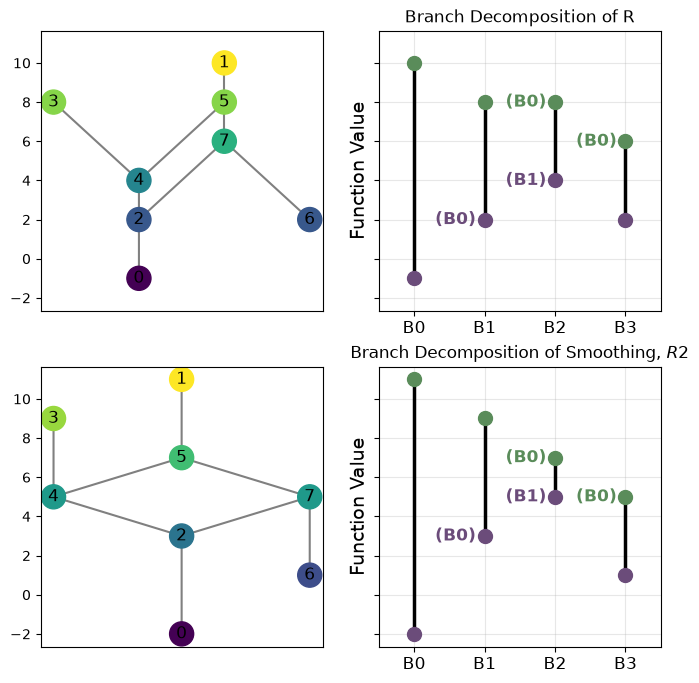

In [11]:
fig, ax = plt.subplots(2,2, figsize=(8,8),sharey=True)
R.draw(ax = ax[0,0]);
myB.draw(ax = ax[0,1]);
ax[0,1].set_title("Branch Decomposition of R", fontsize=12)
ax[0,1].set_xlabel("")
myB2.draw(ax = ax[1,1]);
R2.draw(ax = ax[1,0]);
ax[1,1].set_title("Branch Decomposition of Smoothing, $R2$", fontsize=12)
ax[1,1].set_xlabel("");

# Print out the branch map to be able to compare
for i in range(len(myB)):
    print(f"Branch {i} |--> {branch_map[i]}")

In [12]:
# And just some more checks
for i in range(len(branch_map.source)): # Note this should be the same as myB since it's stored internally 
    print(f"\nBranch B{i} in R corresponds to path {branch_map[i]} in the branch decomposition of R2.")
    print(f"Check {branch_map[i]} is a valid path: {myB2.check_branch_path(branch_map[i])}")


Branch B0 in R corresponds to path [0] in the branch decomposition of R2.
Check [0] is a valid path: True

Branch B1 in R corresponds to path [0, 1] in the branch decomposition of R2.
Check [0, 1] is a valid path: True

Branch B2 in R corresponds to path [1, 2, 0] in the branch decomposition of R2.
Check [1, 2, 0] is a valid path: True

Branch B3 in R corresponds to path [3, 0] in the branch decomposition of R2.
Check [3, 0] is a valid path: True


So now what I want to be able to do is take a path in $R$, which probably means I actually want a path plus an interval $[a,b]$ since we need to end up with the subimage of the path in that thing, and spit out the image of that path in $R2$.

> **Warning**: Technically the function values of path [0,1,2] in R are at most in the interval [0,8]. We're asking for stuff here that goes up to 9 but there's no error since the last image branch ($B_0'$) has higher image. Not sure this is going to be a problem but perhaps worth noting.

Image of path [0, 1, 2] restricted to height [3, 9]
	 in the branch decomposition of R2 is branches: [1, 2, 0]
Image of path [3, 0] restricted to height [3, 9]
	 in the branch decomposition of R2 is branches: [3, 0]
Image of path [0, 1, 2, 0] restricted to height [3, 9]
	 in the branch decomposition of R2 is branches: [1, 2, 0]


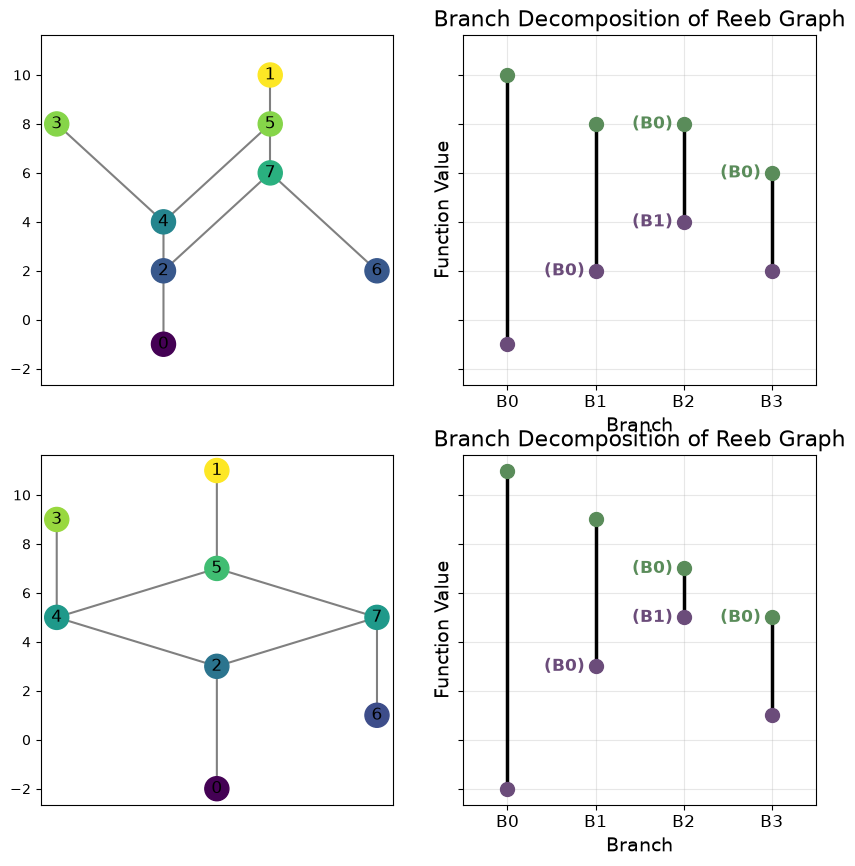

In [13]:
for path in paths_to_check:
    image = myB.path_image(path, 3, 9, branch_map)
    image_indices = [myB2._index_of_branch(branch) for branch in image]
    print(
        f"Image of path {path} restricted to height [3, 9]\n\t "
        f"in the branch decomposition of R2 is branches: {image_indices}"
    )

fig, ax = plt.subplots(2,2, figsize=(10,10), sharey=True)
R.draw(ax = ax[0,0]);
myB.draw(ax = ax[0,1]);
R2.draw(ax = ax[1,0]);
myB2.draw(ax = ax[1,1]);

## Smoothing

Now the goal is to actually construct the smoothed Reeb graph from the input, and to track the maps at the same time. 

The basic idea will be to iteratively add each branch in turn. At any stopping point of the algorithm, the smoothed branch decomposition will be correct for the smoothing of the Reeb graph built from the already seen branches. 

Working on branch 0: (-1.0, 10.0)
Case 1a: Local min/max
Working on branch 1: (2.0, 8.0)
Case 2a: Up fork / local max
Working on branch 2: (4.0, 8.0)
Case 2a: Up fork / local max
Case 2b: Up fork/down fork
Working on branch 3: (2.0, 6.0)
Case 1a: Local min/max
Case 1b: Local min/down fork
Branch 0 in R corresponds to path [0] in the branch decomposition of the smoothing.
Branch 1 in R corresponds to path [0, 1] in the branch decomposition of the smoothing.
Branch 2 in R corresponds to path [1, 2, 0] in the branch decomposition of the smoothing.
Branch 3 in R corresponds to path [3, 0] in the branch decomposition of the smoothing.


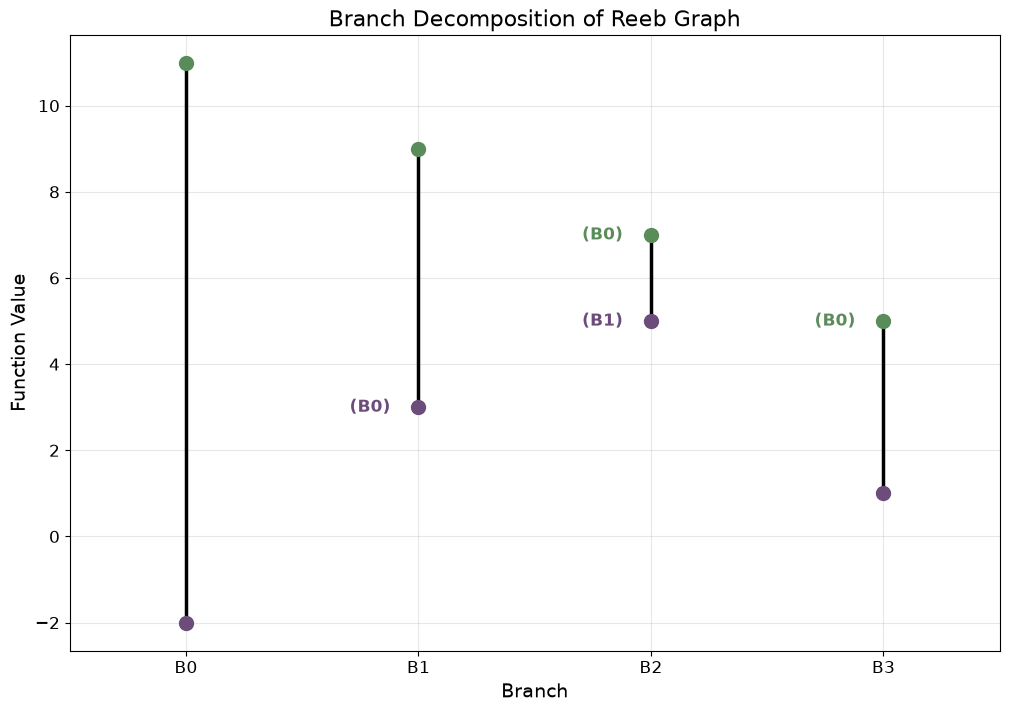

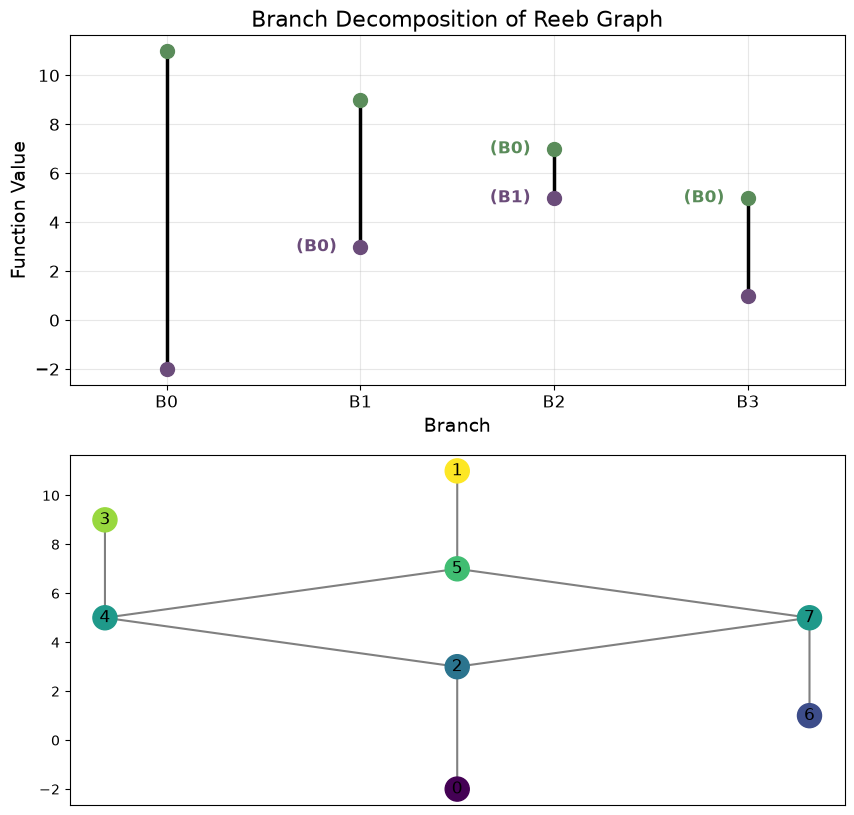

In [31]:
(outSmoothing, outMap) = myB.smooth(1)
outSmoothing.draw()

for i in range(len(myB)):
    print(f"Branch {i} in R corresponds to path {outMap[i]} in the branch decomposition of the smoothing.")

fig, ax = plt.subplots(2, figsize=(10,10), sharey=True)
outSmoothing.draw(ax = ax[0]);
outSmoothing.reconstruct().draw(ax = ax[1]);

Let's make another example to play with. This one is actually going to be only a tree so that we don't have to deal with the not-yet-implemented problem. 

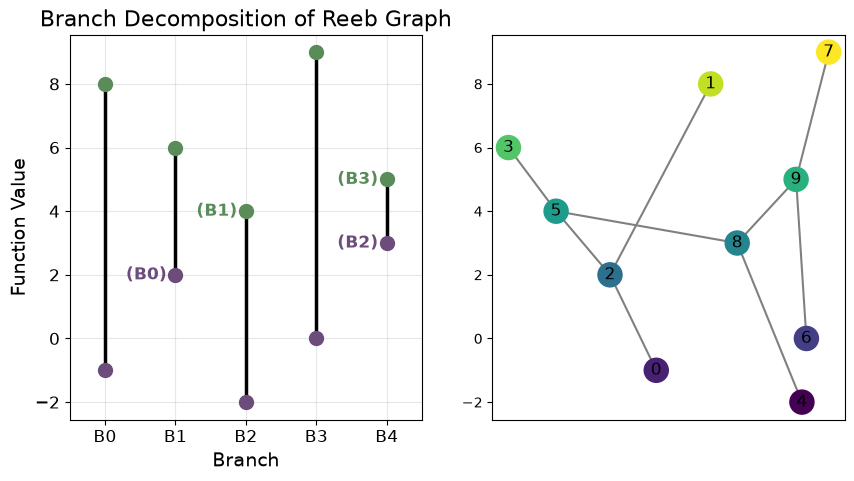

In [32]:
T = branch.BranchDecomp()
T.append(-1,8)
T.append(2,6,bottom_branch = 0)
T.append(-2,4,top_branch = 1)
# J/K After this, we will have a upfork down fork branch, even though it's a tree. 
T.append(0,9)
T.append(3,5, bottom_branch = 2, top_branch = 3)

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
T.draw(ax = ax[0]);
T_reeb = T.reconstruct()
T_reeb.draw(ax = ax[1]);


Working on branch 0: (-1.0, 8.0)
Case 1a: Local min/max
Working on branch 1: (2.0, 6.0)
Case 2a: Up fork / local max
Working on branch 2: (-2.0, 4.0)
Case 1a: Local min/max
Case 1b: Local min/down fork
Working on branch 3: (0.0, 9.0)
Case 1a: Local min/max
Working on branch 4: (3.0, 5.0)
Case 2a: Up fork / local max
Case 2b: Up fork/down fork
Branch 0 in T corresponds to path [0] in the branch decomposition of the smoothing.
Check [0] is a valid path: True
Branch 1 in T corresponds to path [0, 1] in the branch decomposition of the smoothing.
Check [0, 1] is a valid path: True
Branch 2 in T corresponds to path [2, 1] in the branch decomposition of the smoothing.
Check [2, 1] is a valid path: True
Branch 3 in T corresponds to path [3] in the branch decomposition of the smoothing.
Check [3] is a valid path: True
Branch 4 in T corresponds to path [2, 1, 4, 3] in the branch decomposition of the smoothing.
Check [2, 1, 4, 3] is a valid path: True
Check: [2, 1, 4, 3] is a valid path in T_smoo

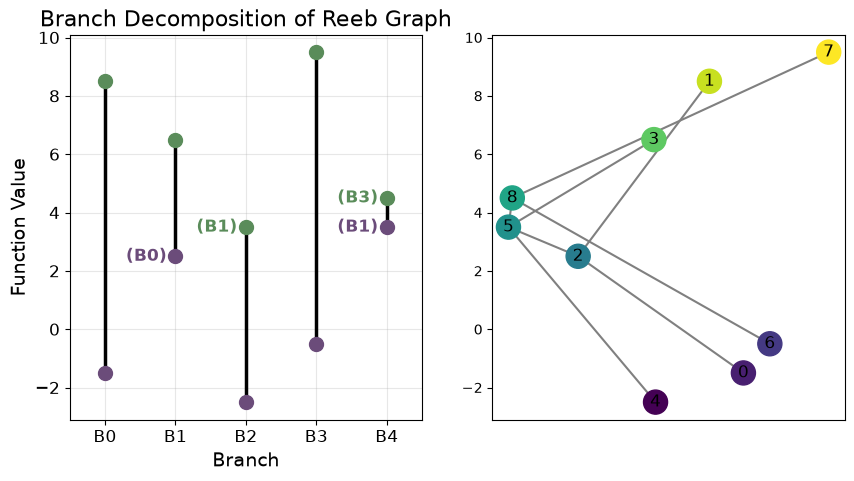

In [30]:
T_smooth, eta = T.smooth(0.5)

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
T_smooth.draw(ax = ax[0]);
T_smooth.reconstruct().draw(ax = ax[1]);

for i in range(len(T)):
    print(f"Branch {i} in T corresponds to path {eta[i]} in the branch decomposition of the smoothing.")
    print(f"Check {eta[i]} is a valid path: {T_smooth.check_branch_path(eta[i])}")

print(f"Check: {[2,1,4,3]} is a valid path in T_smooth: {T_smooth.check_branch_path([2,1,4,3])}")

## Smoothing - OLD VERSION

> **Warning:** I've update the stuff above here, although a good careful check is a good idea. Nothing below here is updated to the new version yet. 


Now we want to do smoothing! I need a new example to use while I'm testing. It's actually almost the same as the previous but I reordered the branches (same resulting Reeb graph!) and I increased the epsilon to 3 for the manual smoothing version. 

In [30]:
myB = branch.BranchDecomp()
myB.add_branch(-1,10,0,0)
myB.add_branch(2,8,0,1)
myB.add_branch(2,6,2,0)
myB.add_branch(4,8,1,0)

R = myB.reconstruct()
fig, ax = plt.subplots(2,2, figsize=(15,15),sharey=True)
R.draw(ax = ax[0,0]);
myB.draw(ax = ax[0,1]);

branch_map = {}
myB2 = branch.BranchDecomp()
myB2.add_branch(-3,12,0,0)
branch_map[0] = [0]
myB2.add_branch(4,10,0,1)
branch_map[1] = [0,1]
myB2.add_branch(5,7,1,0)
branch_map[2] = [1,2,0]
myB2.add_branch(2,5,3,0)
branch_map[3] = [3,0]

myB2.draw(ax = ax[1,1]);
R2 = myB2.reconstruct()
R2.draw(ax = ax[1,0]);

AttributeError: 'BranchDecomp' object has no attribute 'add_branch'

And now! For the main event! We're going to implement smoothing! 

<div style="color: #d00000; font-weight: 900; font-size: 1.2rem;">
  🚨 WARNING
</div>

Right now, this only actually works for trees. Non-trees have branches that have both endpoints as non-extrema (so an up fork on the bottom, and a down fork on the top). You can pass in things that have those guys, but you'll end up with just a hanging around branch. 

In [ ]:
# TODO: I've moved teh previous functions into the branchdecomp.py file, so this needs to be updated to use those. Also should just be moved into the branchdecomp.py itself so that we aren't doing this in a jupyter notebook.

def smoothing(branch_decomp, eps): 
    """Given a branch decomposition of a Reeb graph, we want to return the branch decomposition of the smoothed Reeb graph, with parameter epsilon. We will also return the branch_map which gives the path in the smoothed Reeb graph which is the image of a branch from the input Reeb graph.

    Args:
        branch_decomp (branch.BranchDecomposition): The branch decomposition of the input Reeb graph.
        eps (float): The smoothing parameter.
    
    Returns:
        tuple: A tuple containing the smoothed branch decomposition and the branch map.
    """
    
    # Check that Epsilon is positive. If not, return an error.
    if eps <= 0:
        raise ValueError("Epsilon must be positive.")
        
    # Create a new branch decomposition object for the smoothed Reeb graph.
    smoothed_branch_decomp = branch.BranchDecomp()
    
    # Create the branch map dictionary to keep track of the mapping from branches in the input decomposition to paths in the smoothed decomposition.
    branch_map = {}
    
    for i in range(branch_decomp._num_branches):
        # Get the interval for the current branch.
        low = branch_decomp._branch_values[i, 0]
        high = branch_decomp._branch_values[i, 1]
        
        if branch_decomp._branch_attach[i, 0] == i: # Bottom is a local min
            if branch_decomp._branch_attach[i, 1] == i: # Top is a local max
                # print(f"\nWorking on B{i}, (local min, local max) case.")
                # This means that both the top and bottom are local extrema, so we add a new branch with extended interval and no attachments. 
                new_branch_num = smoothed_branch_decomp._num_branches
                smoothed_branch_decomp.add_branch(low-eps, high+eps, new_branch_num, new_branch_num)
                branch_map[i] = [new_branch_num]
            
            else: # (Local min, down fork) case
                # print(f"\nWorking on B{i}, (local min, downfork) case.")
                # The new branch will have interval [low-eps,high-eps]. 
                new_branch_num = smoothed_branch_decomp._num_branches
                
                # Starting with the down fork attachment, path_in_old will give the path of branches we get to by following the attaching information down from the top attachment of the current branch until we get to a branch that is below high-eps.
                check_attach_top = branch_decomp._branch_attach[i, 1]
                path_in_old = [check_attach_top] 
                
                # While the check_attach_top branch doesn't have a local min at the bottom but the function value at the bottom is still above high-eps, we keep following the attaching information down.
                while branch_decomp._branch_attach[check_attach_top, 0] != check_attach_top and branch_decomp._branch_values[check_attach_top, 0] >= high - eps:
                    check_attach_top = branch_decomp._branch_attach[check_attach_top, 0]
                    path_in_old.append(check_attach_top)
                
                print(f"Path in old branch decomposition to attach new branch for B{i}: {path_in_old}")
                
                # Attachment for top of new branch is the image (in the smoothed graph) of the last branch in path_in_old at the height value high-eps.
                # We get this from the function find_subpath 
                new_attach_top = find_subpath(smoothed_branch_decomp, branch_map[path_in_old[-1]], high-eps)[0]
                
                # Attaching maps are bottom is attached to itself, top is attached to new_attach_top
                smoothed_branch_decomp.add_branch(low-eps,high-eps, new_branch_num, new_attach_top)

                # Reverse the branch map because branch paths go up in the Reeb graph, but this one went down
                path_in_old = list(reversed(path_in_old))
                
                print(f"Reversed path: {path_in_old}")
                
                # Now get the image of this path in the new branch decomposition using the branch map.
                # We need to restrict the image to the interval 
                # (max(high-eps,low) , high)
                # since that's the portion that would actually get mapped there. Then after the fact, we add the new branch as a tail at the end.
                branch_map[i] = path_image(path_in_old, max(high-eps,low), high, branch_decomp, smoothed_branch_decomp, branch_map)
                
                print(f"Image of old-path {path_in_old} for range ({max(high-eps,low)},{high}) in new branch decomposition: {branch_map[i]}")

                # If new high (high-eps) is above low, then the bottom of the branch gets mapped to the new branch, so we need to add that to the beginning of the image as well.
                if high-eps > low :
                    branch_map[i].insert(0, new_branch_num)

                # Add a check for valid path 
                if not check_branch_path(smoothed_branch_decomp, branch_map[i]):
                    print(f" local min, down fork case made a bad path for branch {i}: {branch_map[i]}")
                
        else: # Bottom is an up fork 
            if branch_decomp._branch_attach[i, 1] == i: # (upfork, local max) case
                # print(f"\nWorking on B{i}, (upfork, local max) case.")
                # The new branch will have interval [low+eps, high+eps]. 
                new_branch_num = smoothed_branch_decomp._num_branches
                
                # Starting with the up fork attachment, path_in_old will give the path of branches we get to by following the attaching information up from the bottom attachment of the current branch until we get to a branch that contains low+eps.
                check_attach_bottom = branch_decomp._branch_attach[i, 0]
                path_in_old = [check_attach_bottom] 

                # While 
                #   - There is still a next branch to follow up at the top (which means branch_decomp._branch_attach[check_attach_bottom, 1] != check_attach_bottom )
                #   - The value a low+eps is not in the check_attach_bottom branch's interval (which means branch_decomp._branch_values[check_attach_bottom, 1] < low + eps. If the top of the branch checking is above low+eps, then we know low+eps is in that branch's interval since the bottom is attached to the previous branch in the path which is below low+eps).
                while branch_decomp._branch_attach[check_attach_bottom, 1] != check_attach_bottom and branch_decomp._branch_values[check_attach_bottom, 1] < low + eps:
                    check_attach_bottom = branch_decomp._branch_attach[check_attach_bottom, 1]
                    path_in_old.append(check_attach_bottom)
                
                # Attachment for bottom of new branch is the image of the last branch in path_in_old at the height value low+eps. We get this from the function find_subpath 
                new_attach_low = find_subpath(smoothed_branch_decomp, branch_map[path_in_old[-1]], low+eps)[0]
                
                # Attaching maps are top is attached to itself, bottom is attached to new_attach_low
                smoothed_branch_decomp.add_branch(low+eps, high+eps, new_attach_low, new_branch_num)

                # Now get the image of this path in the new branch decomposition using the branch map.
                # Like before, we need to restrict the image to the interval (low, min(low+eps,high)) since that's the portion that would actually get mapped there. Then after the fact, we add the new branch as a head at the beginning.
                branch_map[i] = path_image(path_in_old, low, min(low+eps,high), branch_decomp, smoothed_branch_decomp, branch_map)
                
                # If new low (low+eps) is below high, then the top of the branch gets mapped to the new branch, so we need to add that to the image as well.
                if high > low + eps: 
                    branch_map[i].append(new_branch_num)
  
                # Add a check for valid path 
                if not check_branch_path(smoothed_branch_decomp, branch_map[i]):
                    print(f" upfork, local max case made a bad path for branch {i}: {branch_map[i]}")                   
                
            else: # Top and bottom are both forks. This is the hard one.
                print(f"\nWarning: B{i} is an (upfork, downfork) case. - NOT IMPLEMENTED YET")
                if high-low <= 2*eps:
                    # This is a short edge. It will go away, but how it does needs to be determined. 
                    
                    # TODO Update mapping 
                    branch_map[i] = []
                    pass 
                
                else:
                    # The top will go down and the bottom will go up, so the new branch will have interval [low+eps, high-eps]. 
                    new_branch_low = low+eps
                    new_branch_high = high-eps
                    new_branch_num = smoothed_branch_decomp._num_branches
                    # TODO Fix attaching maps
                    smoothed_branch_decomp.add_branch(new_branch_low, new_branch_high, new_branch_num, new_branch_num)
                    # TODO Update mapping
                    branch_map[i] = []
                    
    return smoothed_branch_decomp, branch_map
  


That example above. WARNING: If I haven't finished implementing the last case above, this isn't quite correct yet. 

In [50]:
newB, new_map = smoothing(myB, 4)

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
myB.draw(ax = ax[0]);
newB.draw(ax = ax[1]);

for i in new_map:
    print(f"Branch B{i} in R corresponds to path {new_map[i]} in the branch decomposition of R2.")
    # print(f"Check {new_map[i]} is a valid path: {check_branch_path(myB2, new_map[i])}")

NameError: name 'find_subpath' is not defined

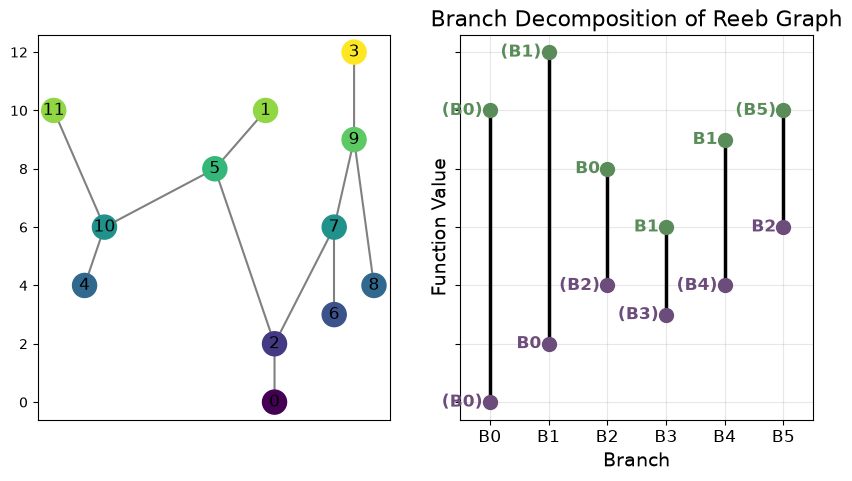

In [ ]:
# A larger example but only a tree so that we can check that part. 

treeB = branch.BranchDecomp()
treeB.add_branch(0,10,0,0)
treeB.add_branch(2,12,0,1)
treeB.add_branch(4,8,2,0)
treeB.add_branch(3,6,3,1)
treeB.add_branch(4,9,4,1)
treeB.add_branch(6,10,2,5)

T = treeB.reconstruct()
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
T.draw(ax = ax[0]); 
treeB.draw(ax = ax[1]);

Path in old branch decomposition to attach new branch for B2: [np.int64(0)]
Reversed path: [np.int64(0)]
Image of old-path [np.int64(0)] for range (5.0,8.0) in new branch decomposition: [0]
Path in old branch decomposition to attach new branch for B3: [np.int64(1)]
Reversed path: [np.int64(1)]
Image of old-path [np.int64(1)] for range (3.0,6.0) in new branch decomposition: [0, 1]
Path in old branch decomposition to attach new branch for B4: [np.int64(1)]
Reversed path: [np.int64(1)]
Image of old-path [np.int64(1)] for range (6.0,9.0) in new branch decomposition: [1]

Branch B0 in R corresponds to path [0] in the branch decomposition of T2.
Check [0] is a valid path: True

Branch B1 in R corresponds to path [0, 1] in the branch decomposition of T2.
Check [0, 1] is a valid path: True

Branch B2 in R corresponds to path [2, 0] in the branch decomposition of T2.
Check [2, 0] is a valid path: True

Branch B3 in R corresponds to path [0, 1] in the branch decomposition of T2.
Check [0, 1] is 

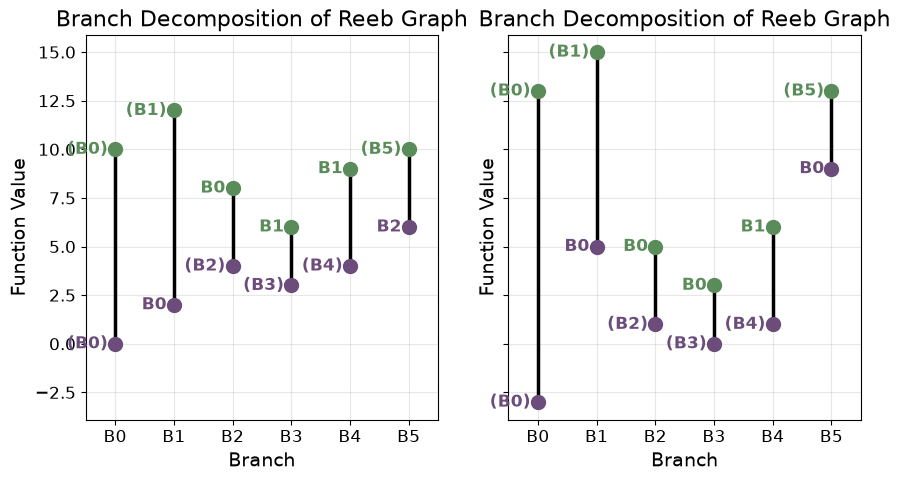

In [ ]:
T2, tree_map = smoothing(treeB, 3);

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
T2.draw(ax = ax[1]);
treeB.draw(ax = ax[0]);

for i in tree_map:
    print(f"\nBranch B{i} in R corresponds to path {tree_map[i]} in the branch decomposition of T2.")
    print(f"Check {tree_map[i]} is a valid path: {check_branch_path(T2, tree_map[i])}")

Path in old branch decomposition to attach new branch for B5: [np.int64(4)]
Reversed path: [np.int64(4)]
Image of old-path [np.int64(4)] for range (4.5,5.5) in new branch decomposition: [3, 4]


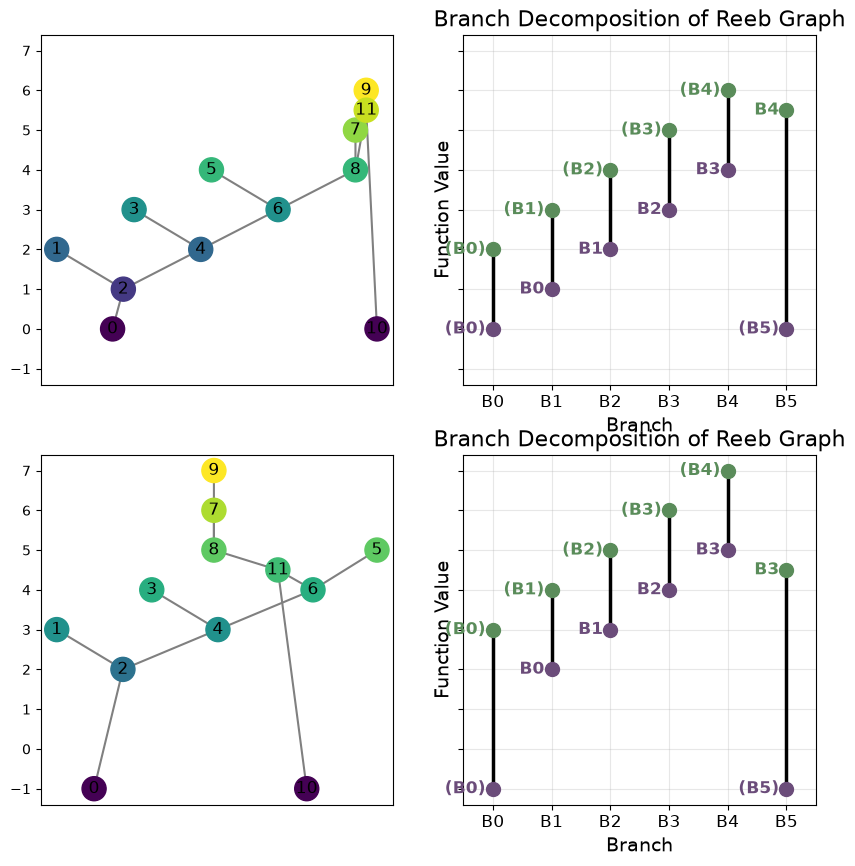

In [ ]:
# Make an example where smoothing will cause a long path for an image branch. 
TreeB = branch.BranchDecomp()
TreeB.add_branch(0,2,0,0)
TreeB.add_branch(1,3,0,1)
TreeB.add_branch(2,4,1,2)
TreeB.add_branch(3,5,2,3)
TreeB.add_branch(4,6,3,4)
TreeB.add_branch(0,5.5,5,4)

fig, ax = plt.subplots(2,2, figsize=(10,10), sharey=True)
TreeB.reconstruct().draw(ax = ax[0,0]);
TreeB.draw(ax = ax[0,1]);

TreeB2, Tree_map = smoothing(TreeB, 1);
TreeB2.reconstruct().draw(ax = ax[1,0]);
TreeB2.draw(ax = ax[1,1]);

In [ ]:
for i in Tree_map:
    print(f"\nBranch B{i} in R corresponds to path {Tree_map[i]} in the branch decomposition of T2.")
    print(f"Check {Tree_map[i]} is a valid path: {check_branch_path(TreeB2, Tree_map[i])}")


Branch B0 in R corresponds to path [0] in the branch decomposition of T2.
Check [0] is a valid path: True

Branch B1 in R corresponds to path [0, 1] in the branch decomposition of T2.
Check [0, 1] is a valid path: True

Branch B2 in R corresponds to path [1, 2] in the branch decomposition of T2.
Check [1, 2] is a valid path: True

Branch B3 in R corresponds to path [2, 3] in the branch decomposition of T2.
Check [2, 3] is a valid path: True

Branch B4 in R corresponds to path [3, 4] in the branch decomposition of T2.
Check [3, 4] is a valid path: True

Branch B5 in R corresponds to path [5, 3, 4] in the branch decomposition of T2.
Check [5, 3, 4] is a valid path: True
